Temp as varaiable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/final.csv")

In [3]:
# Drop unwanted columns
df = df.drop(columns=['_id_x', '_id_y'])

# Datetime handling
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')

# Feature
df['hour'] = df['datetime'].dt.hour

# Drop NaN
df = df.dropna()

In [4]:
Y = df['wdLoad'].values        # outcome
T = df['temp'].values          # treatment
X = df[['hour','rh']].values   # controls

In [5]:
model = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model.fit(Y, T, X=X)

In [ ]:
effects = model.const_marginal_effect(X)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288897 entries, 0 to 288896
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype              
---  ------    --------------   -----              
 0   datetime  288897 non-null  datetime64[ns, UTC]
 1   wdLoad    288897 non-null  float64            
 2   temp      288897 non-null  float64            
 3   rh        288897 non-null  float64            
 4   hour      288897 non-null  int32              
dtypes: datetime64[ns, UTC](1), float64(3), int32(1)
memory usage: 12.1 MB


In [7]:
effects.shape

In [8]:
ate = np.mean(effects)
print("ATE (Temperature):", ate)

ATE (Temperature): 9.437506658579718


hour
0.0      6.403913
1.0      6.538949
2.0      8.276858
3.0      9.788593
4.0     10.549448
5.0     10.563961
6.0     11.228497
7.0     11.423596
8.0     11.812992
9.0     12.067297
10.0    10.729195
11.0    10.194659
12.0     9.329735
13.0     9.388082
14.0     9.568528
15.0     9.690035
16.0     9.796408
17.0     9.627868
18.0     9.996372
19.0     9.568508
20.0     8.710115
21.0     7.705848
22.0     7.227711
23.0     6.863383
Name: effect, dtype: float64


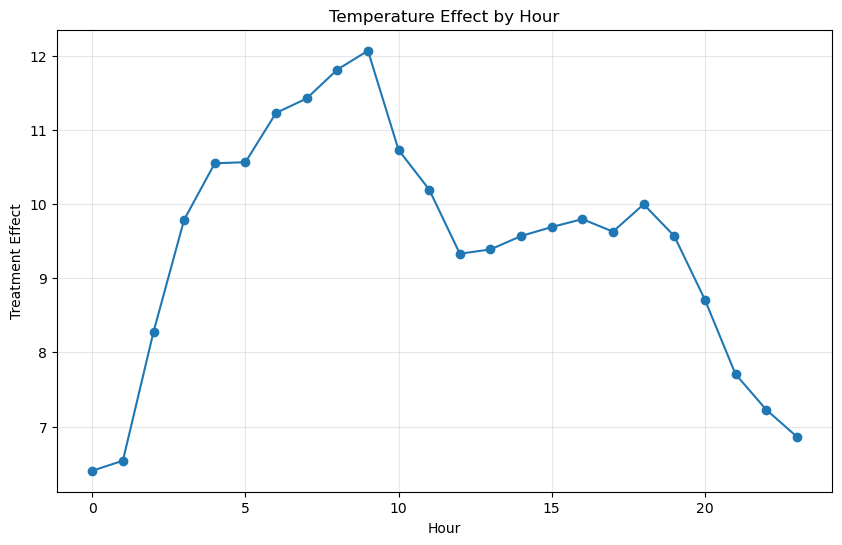

In [8]:
df_effect = pd.DataFrame(X, columns=['hour','rh'])
df_effect['effect'] = effects

effect_by_hour = df_effect.groupby('hour')['effect'].mean()
print(effect_by_hour)
plt.figure(figsize=(10,6))
plt.plot(effect_by_hour.index, effect_by_hour.values, marker='o')

plt.xlabel("Hour")
plt.ylabel("Treatment Effect")
plt.title("Temperature Effect by Hour")

plt.grid(alpha=0.3)
plt.show()

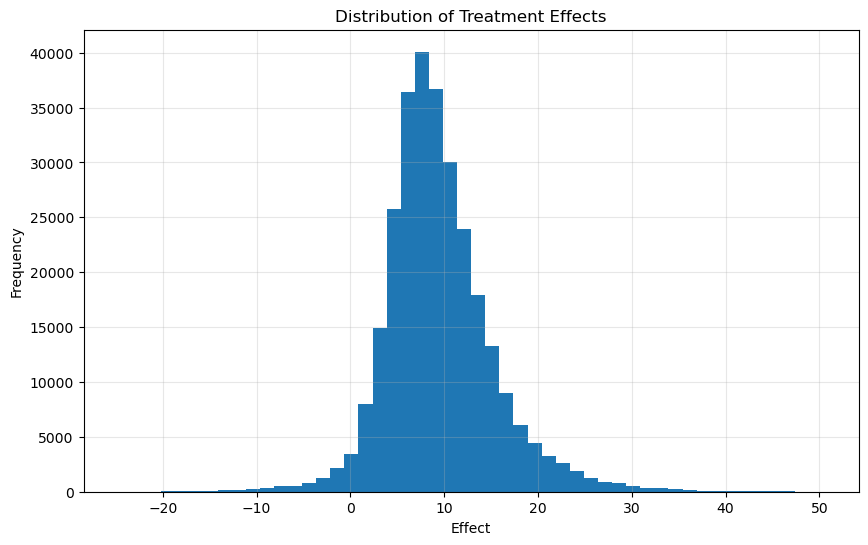

In [9]:
plt.figure(figsize=(10,6))

plt.hist(effects, bins=50)

plt.xlabel("Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Treatment Effects")

plt.grid(alpha=0.3)
plt.show()

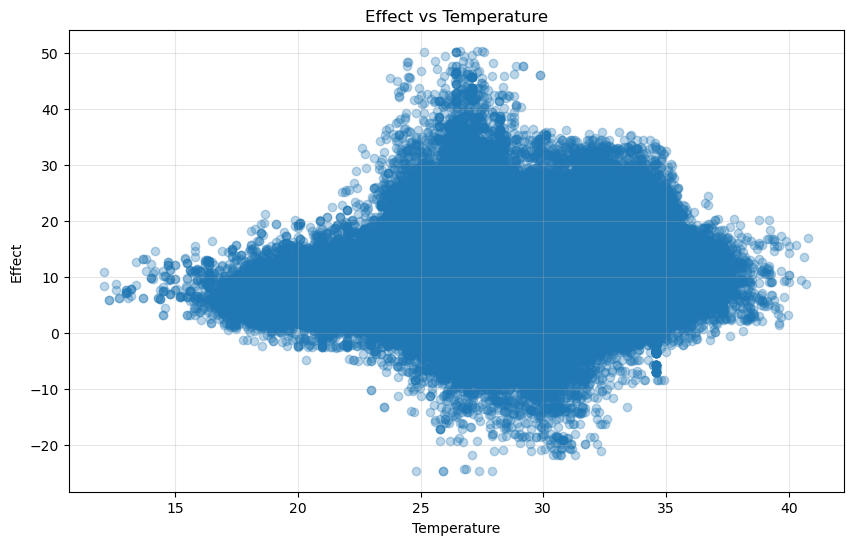

In [17]:
plt.figure(figsize=(10,6))

plt.scatter(df['temp'], effects, alpha=0.3)

plt.xlabel("Temperature")
plt.ylabel("Effect")
plt.title("Effect vs Temperature")

plt.grid(alpha=0.3)
plt.show()

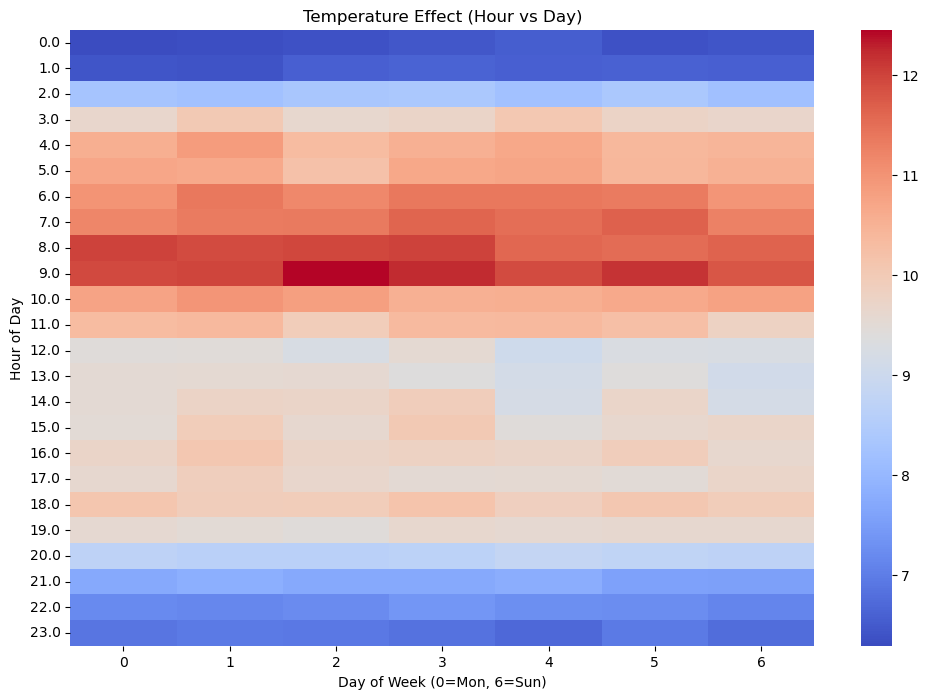

In [19]:
df_effect['dayofweek'] = df['dayofweek'].values

# Pivot table: Hour vs Day
pivot_temp = df_effect.pivot_table(
    values='effect',
    index='hour',
    columns='dayofweek'
)

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(pivot_temp, cmap="coolwarm")

plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.ylabel("Hour of Day")
plt.title("Temperature Effect (Hour vs Day)")

plt.show()

Humoidity as varaiable

In [10]:
# Outcome
Y = df['wdLoad'].values

# Treatment (Humidity)
T_rh = df['rh'].values

# Controls (keep temp + time)
X_rh = df[['hour','temp']].values

In [11]:
model_rh = CausalForestDML(
    model_y=RandomForestRegressor(),
    model_t=RandomForestRegressor(),
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model_rh.fit(Y, T_rh, X=X_rh)

In [12]:
effects_rh = model_rh.effect(X_rh)

In [13]:
ate_rh = np.mean(effects_rh)
print("ATE (Humidity):", ate_rh)

ATE (Humidity): 0.4941600608059098


hour
0.0     0.050120
1.0     0.090594
2.0     0.177615
3.0     0.251014
4.0     0.613672
5.0     0.878681
6.0     1.166516
7.0     1.392043
8.0     1.429668
9.0     1.376726
10.0    1.201153
11.0    1.090055
12.0    0.719300
13.0    0.343582
14.0    0.278501
15.0    0.167247
16.0    0.157281
17.0    0.201020
18.0    0.141015
19.0    0.064614
20.0    0.045772
21.0    0.040950
22.0    0.006702
23.0   -0.022802
Name: effect, dtype: float64


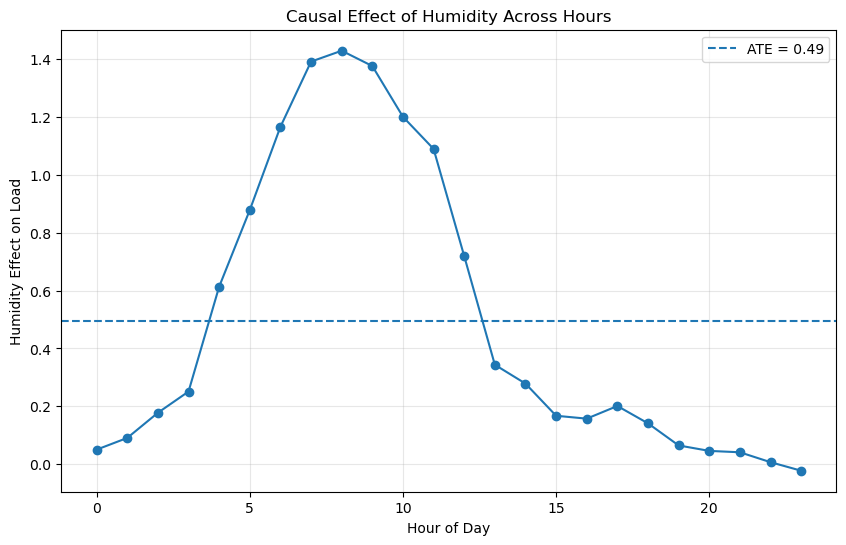

In [14]:

df_effect_rh = pd.DataFrame(X_rh, columns=['hour','temp'])
df_effect_rh['effect'] = effects_rh

effect_by_hour_rh = df_effect_rh.groupby('hour')['effect'].mean()
print(effect_by_hour_rh)
plt.figure(figsize=(10,6))

plt.plot(effect_by_hour_rh.index, effect_by_hour_rh.values, marker='o')
plt.axhline(ate_rh, linestyle='--', label=f'ATE = {ate_rh:.2f}')

plt.xlabel("Hour of Day")
plt.ylabel("Humidity Effect on Load")
plt.title("Causal Effect of Humidity Across Hours")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

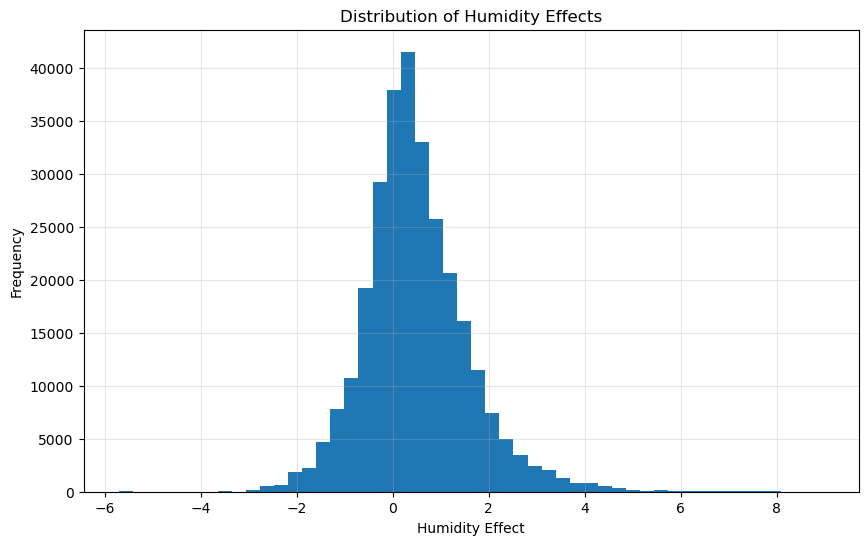

In [15]:
plt.figure(figsize=(10,6))

plt.hist(effects_rh, bins=50)

plt.xlabel("Humidity Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Humidity Effects")

plt.grid(alpha=0.3)
plt.show()

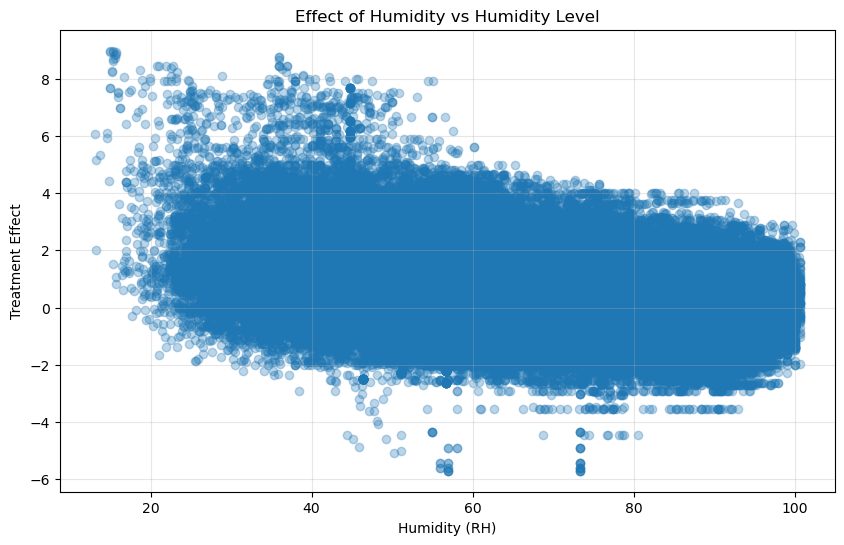

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(df['rh'], effects_rh, alpha=0.3)

plt.xlabel("Humidity (RH)")
plt.ylabel("Treatment Effect")
plt.title("Effect of Humidity vs Humidity Level")

plt.grid(alpha=0.3)
plt.show()

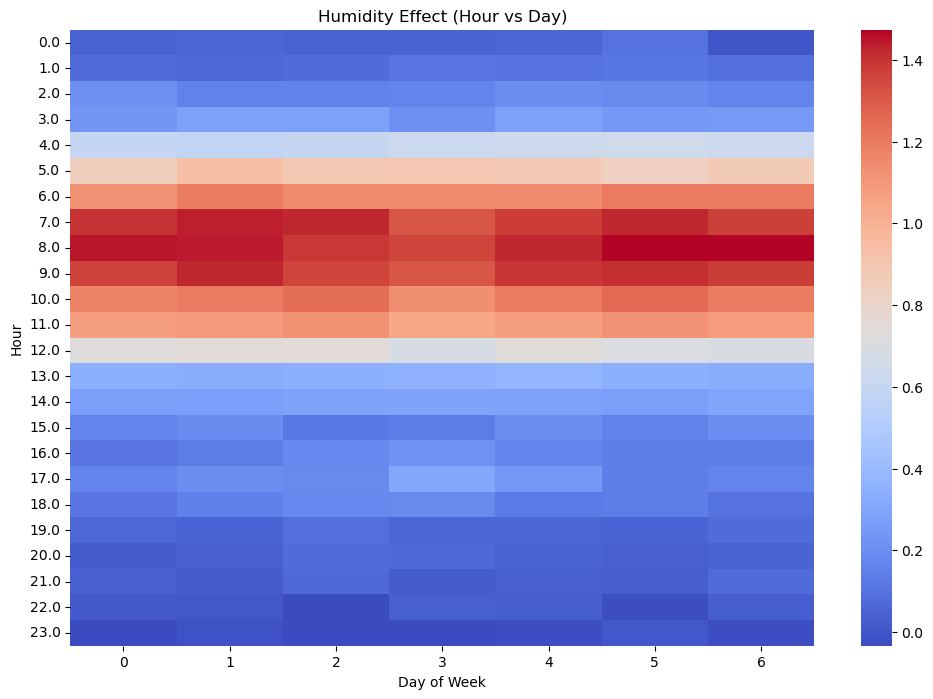

In [18]:
# Add dayofweek if not present
df['dayofweek'] = df['datetime'].dt.dayofweek

df_effect_rh['dayofweek'] = df['dayofweek'].values

pivot_rh = df_effect_rh.pivot_table(
    values='effect',
    index='hour',
    columns='dayofweek'
)

import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(pivot_rh, cmap="coolwarm")

plt.title("Humidity Effect (Hour vs Day)")
plt.xlabel("Day of Week")
plt.ylabel("Hour")

plt.show()